# PEG PNIPAM Crystallization

## Set up

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
import scipy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter

✓ Workspace ready


## Functions

In [2]:
def read_Samodelkin_info(path):
    df = pd.read_csv(path, sep='\t', index_col=0)
    return df[['Time', 'Temperature', 'Crystalinity', 'D 120', 'D 032', 'q1_Ampl']]

def Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+log_normal_peak(x, I0, q0, s)

def Spheres_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+normal_peak(x, I0, q0, s)

def Monodisperse_spheres(x, scale, R, SLD_sphere, SLD_solvent, bkg): #Scattering of a single homogeneous sphere
    ro = SLD_sphere - SLD_solvent
    V = 4 * np.pi * R**3
    return (scale / V) * (3*V*ro*(np.sin(x*R)-x*R*np.cos(x*R))/(x*R)**3)**2 + bkg
    
def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2) 
        Iq.append(scale* scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    return Iq

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

def average_1d_SAXS(Exp, frames):
    q, I = Exp.get_1d_SAXS()
    I *= 0
    for i in frames:
        q_frame, I_frame = Exp.get_1d_SAXS(i)
        I += I_frame
    I /= len(frames)
    return q, I

## Data

In [3]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_0C"
Exp292_6_0C = BM26_experiment(experiment_path)
Info292_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_0.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_5C"
Exp292_6_5C = BM26_experiment(experiment_path)
Info292_6_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C"
Exp292_6_10C = BM26_experiment(experiment_path)
Info292_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_10C.csv")

In [4]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_10C"
Exp292_12_10C = BM26_experiment(experiment_path)
Info292_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_15C"
Exp292_12_15C = BM26_experiment(experiment_path)
Info292_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_17_5C"
Exp292_12_17_5C = BM26_experiment(experiment_path)
Info292_12_17_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_17_5C.csv")

In [5]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_10C"
Exp292_24_10C = BM26_experiment(experiment_path)
Info292_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_15C"
Exp292_24_15C = BM26_experiment(experiment_path)
Info292_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_20C"
Exp292_24_20C = BM26_experiment(experiment_path)
Info292_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_20C.csv")

In [6]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_0C"
Exp576_6_0C = BM26_experiment(experiment_path)
Info576_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_0C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_10C"
Exp576_6_10C = BM26_experiment(experiment_path)
Info576_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_15C"
Exp576_6_15C = BM26_experiment(experiment_path)
Info576_6_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_15C.csv")

In [7]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_5C"
Exp576_12_5C = BM26_experiment(experiment_path)
Info576_12_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_10C"
Exp576_12_10C = BM26_experiment(experiment_path)
Info576_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_15C"
Exp576_12_15C = BM26_experiment(experiment_path)
Info576_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_15C.csv")

In [8]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_576_24_Cryst_at_15C_bis"
Exp576_24_15C = BM26_experiment(experiment_path)
Info576_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_15C_bis.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_5C"
Exp576_24_5C = BM26_experiment(experiment_path)
Info576_24_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_10C"
Exp576_24_10C = BM26_experiment(experiment_path)
Info576_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_20C"
Exp576_24_20C = BM26_experiment(experiment_path)
Info576_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_20C.csv")

In [9]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_888_24_Cryst_at_15C"
Exp888_24_15C = BM26_experiment(experiment_path)
Info888_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_888_24_Cryst_at_15C.csv")


# Analysis

### Fit plot

In [12]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

C:\Users\LabPC\AppData\Local\Temp\ipykernel_2252\706465067.py:31: RuntimeWarning: invalid value encountered in log
  return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))


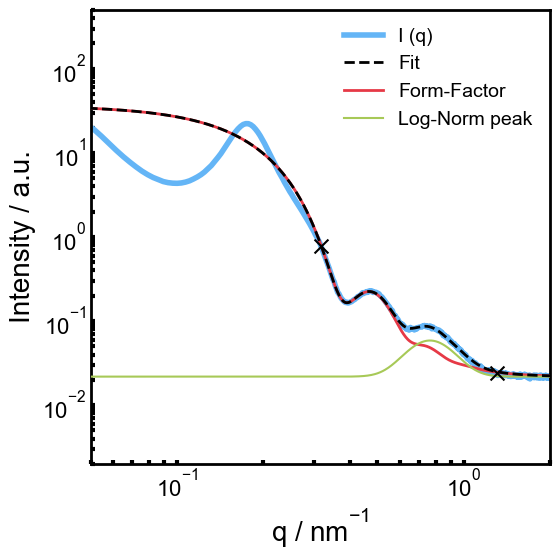

In [13]:
# Создаем фигуру
fig, ax = plt.subplots(figsize=(6, 6))

# Данные
Data = Exp292_6_0C
q, I = Data.get_1d_SAXS(82)
ax.plot(q, I, linewidth=4, color='#64b5f6', label='I (q)')

# Маркеры для области подгонки
l = 90
r = 370
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[1e-6, 11, 0.12, 8.91806121e-03, 5.32180981e-03, 0.8, 0.2])

# Отображение компонентов подгонки
ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

# Настройки графика
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.05, 2)
ax.set_ylim(2e-3, 5e2)

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

plt.tight_layout()
plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig6.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

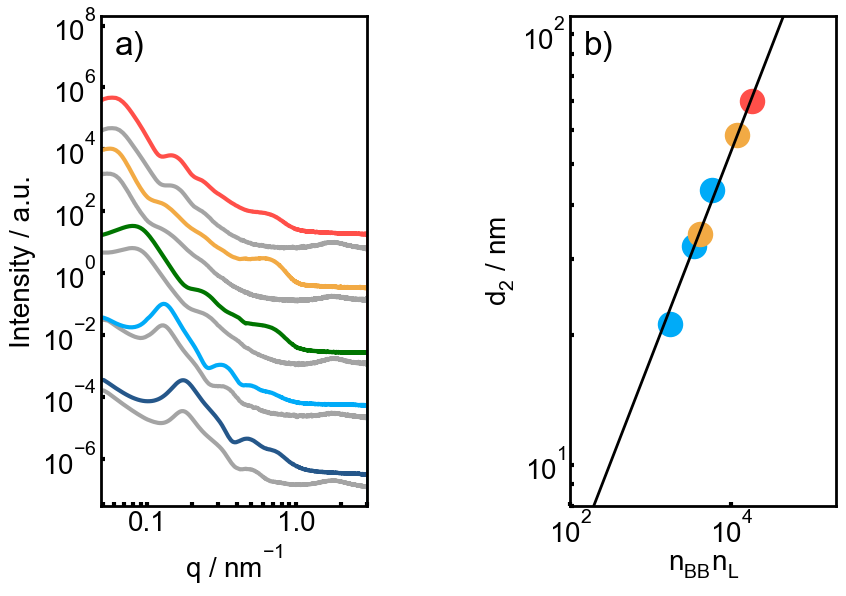

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 7))
fig.subplots_adjust(wspace=20.)

# Общие настройки
linewidth = 3

# ПЕРВЫЙ ГРАФИК (SAXS) - слева
ax1.set_position([0.08, 0.15, 0.38, 0.7])

# Данные для первого графика
grey_color = '#A4A4A4'

q, I = average_1d_SAXS(Exp888_24_15C, [9,10,11,12,13,14,15,16])
ax1.plot(q, (I-0.007)*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp888_24_15C, [i for i in range(74, 84)])
ax1.plot(q, (I*1.5)*1e3, linewidth=linewidth, color='#FF4F49')

q, I = average_1d_SAXS(Exp576_24_15C, [6,7,8,9,10,11,12,13])
I[:68] += 8
I[68:73] += 10
ax1.plot(q, (I-0.009) / 60*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp576_24_15C, [i for i in range(37, 47)])
ax1.plot(q, I / 40*1e3, linewidth=linewidth, color='#F2AA44')

q, I = average_1d_SAXS(Exp292_24_15C, [7,8,9,10,12,13])
ax1.plot(q, (I-0.009)/5000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_24_15C, [i for i in range(52, 62)])
ax1.plot(q, I/5000*1e3, linewidth=linewidth, color='#007500')

q, I = average_1d_SAXS(Exp292_12_15C, [14,15,16,17,18,19,20])
ax1.plot(q, (I-0.007)/200000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_12_15C, [i for i in range(42, 52)])
ax1.plot(q, I/200000*1e3, linewidth=linewidth, color='#00ABF8')

q, I = average_1d_SAXS(Exp292_6_10C, [35,36,37,38,39,40,41,42])
ax1.plot(q, (I-0.0075)/100000000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_6_10C, [i for i in range(83, 93)])
ax1.plot(q, I/50000000*1e3, linewidth=linewidth, color='#25578A')

# Настройки первого графика
ax1.semilogx()
ax1.semilogy()
ax1.set_xlim(0.049, 3)
ax1.set_ylim(3e-11*1e3, 2e5*1e3)

ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.set_xticks([0.1, 1])
ax1.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax1.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax1.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')

# Метка "a)" для первого графика
ax1.text(0.05, 0.97, 'a)', transform=ax1.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)

# ВТОРОЙ ГРАФИК (nBB nL) - справа
ax2.set_position([0.75, 0.15, 0.38, 0.7])

# Настройки осей второго графика
ax2.semilogx()
ax2.semilogy()

ax2.set_xlabel(r'n$_{\mathrm{BB}}$n$_{\mathrm{L}}$', fontsize=20, fontfamily='Arial')
ax2.set_ylabel(r'd$_2$ / nm', fontsize=20, fontfamily='Arial')

ax2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax2.set_yticks([1e1, 1e2])
ax2.set_yticklabels(['$10^1$', '$10^2$'], fontsize=20)
ax2.set_ylim(0.8e1, 1.1e2)
ax2.set_xlim(1e2, 2e5)

# Данные для второго графика
X = np.zeros(6)
Y = np.zeros(6)

nBB = 290
nL = np.array([6,12,20])
x = nL * nBB
ax2.scatter(x, [21.2, 32.2, 43.5], s=300, color='#00ABF8', label='290')
X[:3] = x
Y[:3] = [21.2, 32.2, 43.5]

nBB = 580
nL = np.array([7,20])   
x = nL * nBB
ax2.scatter(x, [34.3, 58.2], s=300, color='#F2AA44', label='580')
X[3:5] = x
Y[3:5] = [34.3, 58.2]

nBB = 890
nL = np.array([20])   
x = nL * nBB
ax2.scatter(x, [69.9], s=300, color='#FF4F49', label='890')
X[5] = x[0]
Y[5] = 69.9

# Функция для аппроксимации
def power(x, a, b):
    return a * x**b

# Аппроксимация
p, cov = curve_fit(power, X, Y)
lnsp = np.linspace(1e2, max(X)*3)
ax2.plot(lnsp, power(lnsp, *p), color='black', linewidth=2)

# Метка "b)" для второго графика
ax2.text(0.05, 0.97, 'b)', transform=ax2.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)

# Легенда для второго графика
#ax2.legend(fontsize=0, frameon=False, prop={'family': 'Arial'}, loc=4)

# Сохраняем график
plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig3.png', dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig3.pdf', bbox_inches='tight', transparent=True)

plt.show()

# Crystallinity fit

### Avrami functions

In [133]:
def Avrami(x, A, k, n):
    return A * (1 - np.exp(-k * x ** n))

def Avrami_shifted(x, A, k, n, x0):
    res = Avrami(abs(x-x0), A, k, n)
    res[x < x0] *= 0
   
    return res
   
def Avraami_2(t, A, K1, n1, K2, n2):
    N = 300
    theta_arr = np.linspace(0, t, N)
 
    res = 0
 
    for theta in theta_arr:
        res += (1 - np.exp(-K2 * (t - theta) ** n2)) * theta ** (n1 - 1) * np.exp(-K1 * (theta ** n1)) * t / N
    return A * K1 * n1 * res
    
def Avraami_2_linspace(t,A, K1, n1, K2, n2):
    res = np.zeros(len(t))
 
    for i in range(len(t)):
        res[i] = Avraami_2(t[i],A, K1, n1, K2, n2)
    return res

def Model(t, A1, K1, n1, A2,  K2, n2):
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

### Results

array([2.98247619e-01, 3.15767977e-07, 2.45156792e+00, 3.26270283e-01,
       2.56394925e-04, 1.48659038e+00])

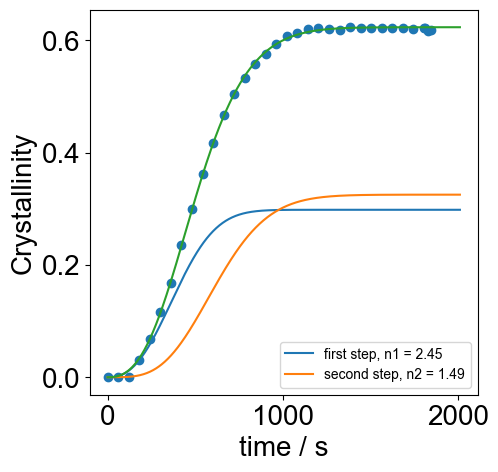

In [159]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_6_10.txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

# plt.scatter(time, 1 - BB)

p, cov = curve_fit(Avrami, time, 1-BB, p0=[1, 1e-8, 3])
# plt.plot(time, Avrami(time, *p))

K1 = p[1]
n1 = p[2]

plt.scatter(time, cr)

epsilon = 1e-10

bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 1], 
          [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

p0 = [0.3, K1, n1, 0.3, 0.00215978, 1.28298]

p, cov = curve_fit(Model, time[:-5], cr[:-5], bounds=bounds, p0=p0)

A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
plt.plot(x,  Model(x, A1, K1, n1, A2,  K2, n2))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


p

In [184]:
time[15]

np.int64(766)

array([3.23249467e-01, 6.25635604e-08, 3.08438223e+00, 3.85871851e-01,
       1.71633759e-03, 1.34700037e+00])

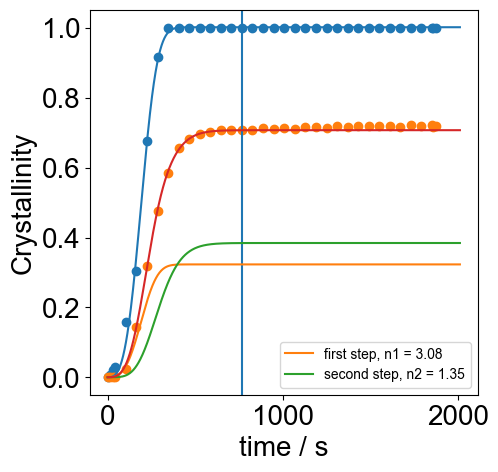

In [193]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_24_10 (1).txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

plt.scatter(time, 1 - BB)

p, cov = curve_fit(Avrami, time[:-20], 1-BB[:-20], p0=[1,  6.8594e-08, 3.06619])
plt.plot(x, Avrami(x, *p))

K1 = p[1]
n1 = p[2]

plt.scatter(time, cr)

epsilon = 1e-10

bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 0], 
          [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

p0 = [0.333906, K1, n1, 0.381534, 0.00215978, 1.28298]

p, cov = curve_fit(Model, time[:15], cr[:15], bounds=bounds, p0=p0)
plt.axvline(time[15])

A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
plt.plot(x, Model(x, *p))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


p

array([2.82828148e-01, 3.30103028e-07, 2.44355904e+00, 3.44366941e-01,
       6.51074538e-04, 1.32969204e+00])

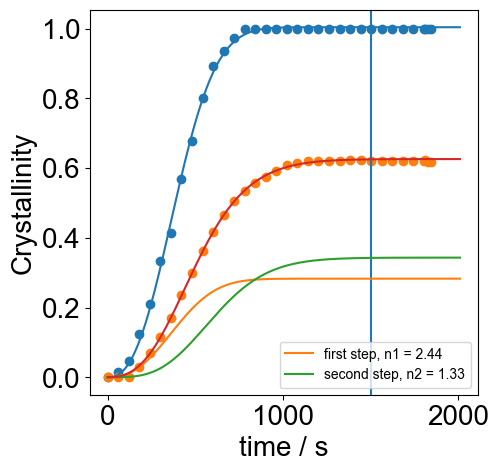

In [201]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_6_10 (1).txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

plt.scatter(time, 1 - BB)

point = 25

p, cov = curve_fit(Avrami, time[:point], 1-BB[:point], p0=[1,  6.8594e-08, 3.06619])
plt.plot(x, Avrami(x, *p))

K1 = p[1]
n1 = p[2]

plt.scatter(time, cr)

epsilon = 1e-10

bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 0], 
          [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

p0 = [0.333906, K1, n1, 0.381534, 0.00215978, 1.28298]

p, cov = curve_fit(Model, time[:point], cr[:point], bounds=bounds, p0=p0)
plt.axvline(time[point])

A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
plt.plot(x, Model(x, *p))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


p

Text(0, 0.5, 'Crystallinity')

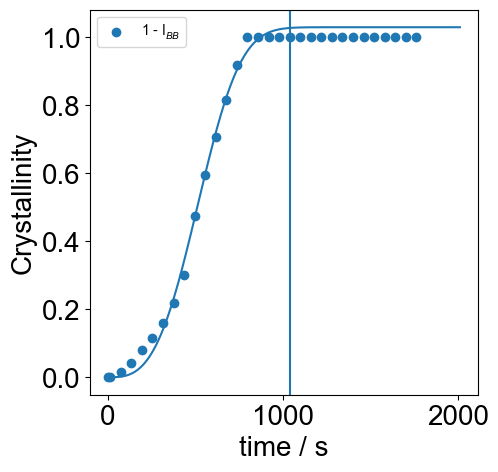

In [214]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_24_15 (1).txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

plt.scatter(time, 1 - BB, label='1 - I$_{BB}$')

point = 18

p, cov = curve_fit(Avrami, time[:point], 1-BB[:point], p0=[1,  6.8594e-08, 3.06619])
plt.plot(x, Avrami(x, *p))
plt.axvline(time[point])

# K1 = p[1]
# n1 = p[2]

# plt.scatter(time, cr)

# epsilon = 1e-10

# bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 0], 
#           [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

# p0 = [0.333906, K1, n1, 0.381534, 0.00215978, 1.28298]

# p, cov = curve_fit(Model, time[:point], cr[:point], bounds=bounds, p0=p0)


# A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

# plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
# plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
# plt.plot(x, Model(x, *p))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


# p